In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 1. Introducción

## 1.1 Calor de reacción

Al ocurrir una reacción química, una cantidad de calor es generada o absorbida por el sistema.

- El calor de reacción corresponde al intercambio de energía entre un sistema y sus alrededores como resultado de una reacción química.

- Para una reacción a presión constante, el calor de reacción es igual al cambio de entalpía, $\Delta_r H$ (entalpía de reacción).

    - $\Delta_r H > 0$: Reacción endotérmica (calor absorbido por el sistema).

    - $\Delta_r H < 0$: Reacción exotérmica (calor generado por el sistema y liberado a los alrededores).

### 1.1.1 Relación entre calor de reacción y temperatura

Dada por la Ley de Hess, que establece que el calor de reacción es independiente del camino de reacción, i.e., las entalpías son aditivas.


$$\Delta H_{r_2} = \Delta H_{r_1} - \overbrace{\left(H_{2} - H_{1}\right)_{\mathrm{reac}}}^{\Delta H_{\mathrm{reactivos}}}  + \overbrace{\left(H_{2} - H_{1}\right)_{\mathrm{prod}}}^{\Delta H_{\mathrm{productos}}} $$

$$C_P = \left(\frac{\partial H}{\partial T}\right)_P$$


$$\Delta H_{r_2} = \Delta H_{r_1} + \int_{T_1}^{T_2} \Delta C_{P} dT$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\Delta H_{r_i}$**: Entalpía de reacción a la temperatura $T_{i}$,  $[\mathrm{J}]$.

- **$H_{i}$**: Entalpía total de los reactivos o productos a la temperatura $T_{i}$,  $[\mathrm{J}]$.

- **$T_{i}$**: Temperatura, $[\mathrm{K}]$.

</div>

</details>

#### Ejemplo

    Levenspiel, Ex. 9.1

Considere una reacción en fase gaseosa que es exotérmica a $298$ $\mathrm{K}$:

$$\mathrm{A + B \rightarrow 2R}$$

$$\Delta H_{r_{298\mathrm{K}}} = -50000 \mathrm{J}$$

Entre $298$ $\mathrm{K}$ $(25^{\circ}\mathrm{C})$ y $1298$ $\mathrm{K}$ $(1025^{\circ}\mathrm{C})$, los valores promediados de capacidad calorífica son:

$$\overline{C_{P_{\mathrm{A}}}}=35 \, [\mathrm{J.mol^{-1}.K^{-1}}]$$
$$\overline{C_{P_{\mathrm{B}}}}=45 \, [\mathrm{J.mol^{-1}.K^{-1}}]$$
$$\overline{C_{P_{\mathrm{C}}}}=70 \, [\mathrm{J.mol^{-1}.K^{-1}}]$$

Calcule la entalpía de reacción en el rango entre $298$ $\mathrm{K}$ $(25^{\circ}\mathrm{C})$ y $1298$ $\mathrm{K}$ $(1025^{\circ}\mathrm{C})$.

In [31]:
Hr1 = -50000 # Hr at 298 K
dCp = lambda T: (2*70) - (35 + 45) # A + B --> 2R

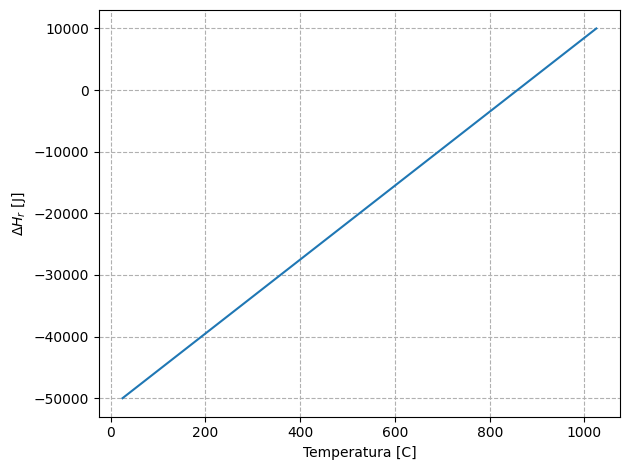

In [32]:
Temps = np.linspace(298, 1298, 20)
Hr = np.empty_like(Temps)

for ii, T in enumerate(Temps):
    Hr[ii] = Hr1 + quad(dCp, 298, T)[0]

fig, ax = plt.subplots()
ax.plot(Temps-273, Hr)
ax.set_xlabel("Temperatura [C]")
ax.set_ylabel(r"$\Delta H_{r}$ [J]")
ax.grid(ls='--')
fig.tight_layout()
plt.show()

## 1.2 Conversión al equilibrio

**El equilibrio termodinámico de una reacción marca los límites teóricos de la conversión que se podría lograr par auna reacción dada. En sistemas reales, no necesariamente se alcanzan estos valores.**

$$\Delta G = \Delta H - T \Delta S$$

$$\Delta_r G = \Delta_r G^{\circ} + RT \ln (Q)$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\Delta_r G$**: Energía libre de Gibbs de la reacción,  $[\mathrm{J}]$.

- **$\Delta_r G^{\circ}$**: Energía libre de Gibbs estándar de la reacción,  $[\mathrm{J}]$.

- **$R$**: Constante universal de los gases,  $8.314\,[\mathrm{J.mol^{-1}.K^{-1}}]$.

- **$T$**: Temperatura, $[\mathrm{K}]$.

- **$Q$**: Cociente de reacción.

</div>

</details>

En equilibrio:

$$\Delta_r G = 0$$

$$\Delta_r G^{\circ} = -RT \ln(K)$$

$$K = \exp \left(\frac{-\Delta_r G^{\circ}}{RT} \right)$$


<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\Delta_r G^{\circ}$**: Energía libre de Gibbs estándar de la reacción,  $[\mathrm{J}]$.

- **$R$**: Constante universal de los gases,  $8.314\,[\mathrm{J.mol^{-1}.K^{-1}}]$.

- **$T$**: Temperatura, $[\mathrm{K}]$.

- **$K$**: Constante de equilibrio.

</div>

</details>

### Relación entre constante de equilibrio y temperatura

La Ecuación de Van't Hoff relaciona los cambios en la constante de equilibrio con respecto a la temperatura del sistema:

$$\frac{d(\ln K)}{dT} = \frac{\Delta_{r} H}{RT^2}$$

<details>
<summary><b>Derivación</b></summary>

<div class="alert alert-info">

Se tienen las ecuaciones:

$$\Delta_{r} G = \Delta_{r} H - T \Delta_{r} S$$

$$\Delta_r G^{\circ} = -RT \ln(K)$$

Se igualan:

$$-RT \ln(K) = \Delta_{r} H - T \Delta_{r} S$$

Se dividen ambos lados entre $-RT$:

$$\ln(K) = -\frac{\Delta_{r}H}{RT} + \frac{\Delta_{r} S}{R}$$

Se deriva con respecto a $T$, considerando que $\Delta_{r}H$, $\Delta_{r}S$ son constantes:

$$\frac{d(\ln K)}{dT} = \frac{\Delta_{r} H}{RT^2}$$

</div>

</details>

La ecuación se integra entre límites apropiados:

$$\int_{K_1}^{K_2} d(\ln K) = \frac{1}{R} \int_{T_1}^{T_2} \frac{\Delta_r H}{T^2} dT$$

Cuando se considera $\Delta_{r}H$ constante, se tiene:

$$\ln \frac{K_2}{K_1} = -\frac{\Delta_{r}H}{R} \left( \frac{1}{T_2} - \frac{1}{T_1} \right)$$

$$\Delta H_{r_i} = \Delta H_{r_0} + \int_{T_0}^{T_i} \Delta C_{P} dT$$

##### Ejemplo

    Levenspiel, Ex. 9.2

Determine la conversión al equilibrio entre $0$ y $100^{\circ}\mathrm{C}$ para la reacción elemental en medio acuoso:

$$A \rightleftarrows R$$

$$\Delta G^{\circ}_{298} = -14130 \, [\mathrm{J.mol^{-1}}]$$

$$\Delta H^{\circ}_{298} = -75300 \, [\mathrm{J.mol^{-1}}]$$

$$C_{P_{\mathrm{A}}} = C_{P_{\mathrm{B}}}$$

**Entalpía de reacción:**

Como $C_{P_{\mathrm{A}}} = C_{P_{\mathrm{B}}}$, entonces $\Delta C_{P} = 0$. Por lo tanto:

$$\Delta_r H = \Delta_r H_{298} = -75300 \, [\mathrm{J.mol^{-1}}]$$

**Constante de equilibrio:**

$$K_{298} = \exp \left(\frac{14130\,\mathrm{J.mol^{-1}}}{(8.314\,\mathrm{J.mol^{-1}.K^{-1}})(298\,\mathrm{K})} \right) \approx 300$$

$$\ln \frac{K}{K_{298}} = -\frac{\Delta_{r}H}{R} \left( \frac{1}{T} - \frac{1}{298} \right)$$

$$K = K_{298} \exp \left[ -\frac{\Delta_{r}H}{R} \left( \frac{1}{T} - \frac{1}{298} \right)  \right]$$

**Relación entre conversión y constante de equilibrio:**

$$K = \frac{C_{\mathrm{R}}}{C_{\mathrm{A}}} = \frac{C_{\mathrm{A}}^0 X_{\mathrm{A}_e}}{C_{\mathrm{A}}^0 (1 - X_{\mathrm{A}_e})} = \frac{X_{\mathrm{A}_e}}{1-X_{\mathrm{A}_e}}$$

Rearreglando:

$$X_{\mathrm{A}_e} = \frac{K}{K+1}$$

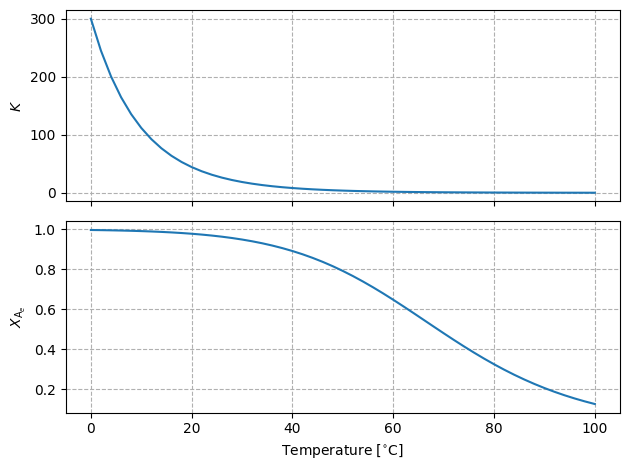

In [33]:
R = 8.314 # J/(mol.K)
dG298 = -14130 # J/mol
dH298 = -75300 # J/mol
dHr = dH298

K298 = np.exp(-dG298 / (R*298))
Keq = lambda T: K298 * np.exp(-dHr/R * (1/T - 1/298))
Xeq = lambda T: Keq(T) / (Keq(T) + 1)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
Temps = np.linspace(0, 100, 51)
ax0.plot(Temps, Keq(Temps+298))
ax1.plot(Temps, Xeq(Temps+298))
ax0.set_ylabel(r"$K$")
ax1.set_ylabel(r"$X_{\mathrm{A}_e}$")
ax1.set_xlabel(r"Temperature [$^{\circ}\mathrm{C}$]")
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()